# Exploración de distribuciones — Río Fonce

Distribuciones de la **evapotranspiración potencial** y del **caudal** en el Fonce (San Gil, IDEAM 24027010) y sus cinco
subcuencas anidadas, a partir de las series diarias de CAMELS-COL (1981–2022).

**Cómo usarlo.** Ejecuta las celdas de arriba hacia abajo. Cambia `ID_ESTACION` en la celda de configuración para mirar otra
estación, o llama a `explorar("caudal_mm", 24027040)` en la última sección. Para agregar una variable (precipitación,
temperatura…) basta una línea en `VARIABLES`: todas las funciones de gráficos sirven para cualquier serie.

**Léelo primero: qué es cada columna**

| Columna | Qué es | Unidad |
|---|---|---|
| `etp` | Evapotranspiración *potencial* escrita en el archivo de CAMELS-COL (`ETP_`), calculada con Hargreaves a partir de la temperatura de MSWX. **No es medida** y no es la evapotranspiración real | mm/día |
| `etp_hg` | La misma fórmula de Hargreaves recalculada aquí con las mismas t_min y t_max y la latitud de la estación | mm/día |
| `caudal` | Caudal medio diario, IDEAM | m³/s |
| `caudal_mm` | `caudal` dividido por el área de la cuenca, para poder comparar estaciones de distinto tamaño | mm/día |

Los archivos de CAMELS-COL **omiten los días sin caudal**, así que todas las series tienen huecos en esos días
(la precipitación y la temperatura también desaparecen en ellos, aunque los productos originales sí los tienen).

## 1. Configuración

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.ticker import LogLocator, FuncFormatter, NullFormatter

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "semibold", "axes.titlesize": 11, "axes.labelsize": 10})
PAL = sns.color_palette("colorblind")          # paleta apta para daltonismo

# raíz del proyecto = primera carpeta padre que contiene data/camels_col
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "camels_col").exists())
DATOS = RAIZ / "data/camels_col/hydromet/3_Hydrometeorological_data"
MAESTRA = pd.read_csv(RAIZ / "out/camels_col_master.csv").set_index("gauge_id")   # atributos de CAMELS-COL, una fila por cuenca

ESTACIONES = {
    24027010: "San Gil (Fonce, salida)",
    24027070: "Mérida (Fonce)",
    24027030: "Nemizaque (Pienta)",
    24027050: "Puente Llano (Taquiza)",
    24027040: "Puente Cabra (Mogoticos)",
    24027060: "Puente Arco (Monchía)",
}
ID_ESTACION = 24027010          # estación que se usa en las figuras de una sola estación
MESES = list("EFMAMJJASOND")
print("raíz del proyecto:", RAIZ)

raíz del proyecto: C:\Users\juanp\OneDrive\Escritorio\Proyectos\U\Hidrologia\Tarea 1 - Analisis de Cuenca


## 2. Carga de los datos

`etp_hg` usa la radiación extraterrestre de FAO-56 con la ecuación de Hargreaves–Samani
(ET₀ = 0.0023 · Ra · (T + 17.8) · √(T_max − T_min), con **Ra en mm/día**). Está aquí solo como verificación de qué tan
razonable es la `etp` del archivo.

In [2]:
def radiacion_extraterrestre(lat_grados, dia_del_anio):
    """FAO-56 ec. 21, en MJ m-2 día-1."""
    phi = np.radians(lat_grados)
    dr = 1 + 0.033 * np.cos(2 * np.pi * dia_del_anio / 365)
    dec = 0.409 * np.sin(2 * np.pi * dia_del_anio / 365 - 1.39)
    ws = np.arccos(np.clip(-np.tan(phi) * np.tan(dec), -1, 1))
    return (24 * 60 / np.pi) * 0.0820 * dr * (ws * np.sin(phi) * np.sin(dec) + np.cos(phi) * np.cos(dec) * np.sin(ws))

def hargreaves(t_min, t_max, lat_grados, dia_del_anio):
    """Hargreaves y Samani (1985); Ra convertida a mm/día (x 0.408)."""
    ra = 0.408 * radiacion_extraterrestre(lat_grados, dia_del_anio)
    return 0.0023 * ra * ((t_min + t_max) / 2 + 17.8) * np.sqrt((t_max - t_min).clip(lower=0))

def cargar_estacion(id_est):
    d = pd.read_csv(DATOS / f"Hydromet_data_{id_est}.txt", sep="\t", encoding="latin-1")
    d.columns = ["fecha", "precip", "etp", "t_min", "t_max", "caudal"]
    d["fecha"] = pd.to_datetime(d["fecha"], format="%d/%m/%Y")
    d = d.set_index("fecha").sort_index()
    d = d.reindex(pd.date_range(d.index.min(), d.index.max(), freq="D"))   # los días faltantes quedan como NaN
    d.index.name = "fecha"
    d["caudal_mm"] = d["caudal"] * 86400 / (MAESTRA.loc[id_est, "area"] * 1e6) * 1000
    d["etp_hg"] = hargreaves(d["t_min"], d["t_max"], MAESTRA.loc[id_est, "lat_wgs84"], d.index.dayofyear.values)
    return d

datos = {id_est: cargar_estacion(id_est) for id_est in ESTACIONES}

VARIABLES = {
    "etp":       dict(col="etp",       etiqueta="Evapotranspiración potencial (archivo: ETP_)",           unidad="mm/día", log=False),
    "etp_hg":    dict(col="etp_hg",    etiqueta="Evapotranspiración potencial (Hargreaves, recalculada)", unidad="mm/día", log=False),
    "caudal":    dict(col="caudal",    etiqueta="Caudal",                unidad="m³/s",   log=True),
    "caudal_mm": dict(col="caudal_mm", etiqueta="Caudal específico",     unidad="mm/día", log=True),
}

resumen = pd.DataFrame({
    ESTACIONES[i]: {
        "días del calendario": len(d), "días con caudal": int(d.caudal.notna().sum()),
        "caudal faltante (%)": round(100 * d.caudal.isna().mean(), 2),
        "área (km²)": round(MAESTRA.loc[i, "area"]),
        "caudal medio (m³/s)": round(d.caudal.mean(), 1), "ETP archivo media (mm/d)": round(d.etp.mean(), 2),
    } for i, d in datos.items()
}).T.astype({"días del calendario": int, "días con caudal": int, "área (km²)": int})
resumen

,días del calendario,días con caudal,caudal faltante (%),área (km²),caudal medio (m³/s),ETP archivo media (mm/d)
"San Gil (Fonce, salida)",15340,14410,6.06,2124,88.0,9.31
Mérida (Fonce),15340,14590,4.89,1578,64.9,9.12
Nemizaque (Pienta),15340,14416,6.02,635,26.8,8.62
Puente Llano (Taquiza),15340,14581,4.95,614,25.5,8.87
Puente Cabra (Mogoticos),15340,15261,0.51,185,6.5,9.59
Puente Arco (Monchía),15340,15037,1.98,167,8.6,9.68


## 3. Funciones de gráficos

`panel_distribucion` muestra cuatro vistas de una serie: **histograma + KDE**, **distribución acumulada empírica**,
**diagramas de caja por mes** (estacionalidad) y un **gráfico Q–Q** contra la normal (de los logaritmos cuando `log=True`).
Las otras tres funciones superponen todas las estaciones.

In [3]:
def marcas_log_legibles(eje):
    """Marcas 1-2-5 legibles en un eje logarítmico."""
    eje.set_major_locator(LogLocator(base=10, subs=(1, 2, 5), numticks=12))
    eje.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    eje.set_minor_locator(LogLocator(base=10, subs=np.arange(1, 10), numticks=12))
    eje.set_minor_formatter(NullFormatter())

def panel_distribucion(serie, etiqueta, unidad, log=False, color=None):
    """Cuatro vistas de una serie diaria. Devuelve una tabla resumen."""
    s = serie.dropna()
    if log:
        descartados = int((s <= 0).sum()); s = s[s > 0]
        if descartados: print(f"nota: {descartados} valor(es) no positivo(s) quedan fuera de los gráficos en escala log")
    color = color or PAL[0]
    fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    fig.suptitle(f"{etiqueta}  [{unidad}]", fontsize=13, fontweight="semibold")

    a = ax[0, 0]
    sns.histplot(s, bins=50, kde=True, log_scale=log, color=color, ax=a)
    a.axvline(s.mean(), color="k", ls="--", lw=1, label=f"media {s.mean():.2f}")
    a.axvline(s.median(), color="k", ls=":", lw=1.5, label=f"mediana {s.median():.2f}")
    if log: marcas_log_legibles(a.xaxis)
    a.set(title="Histograma + KDE", xlabel=unidad, ylabel="días"); a.legend(frameon=False)

    a = ax[0, 1]
    x = np.sort(s.values); y = np.arange(1, len(x) + 1) / len(x)
    a.plot(x, y, color=color, lw=2)
    for p in (0.05, 0.5, 0.95): a.axhline(p, color="0.6", lw=0.8, ls=":")
    if log: a.set_xscale("log"); marcas_log_legibles(a.xaxis)
    a.set(title="Distribución acumulada empírica", xlabel=unidad, ylabel="P(X ≤ x)")

    a = ax[1, 0]
    df = pd.DataFrame({"v": s.values, "m": s.index.month})
    sns.boxplot(data=df, x="m", y="v", color=color, showfliers=False, linewidth=1, ax=a)
    a.set_xticks(range(12)); a.set_xticklabels(MESES)
    if log: a.set_yscale("log"); marcas_log_legibles(a.yaxis)
    a.set(title="Por mes (sin valores atípicos)", xlabel="", ylabel=unidad)

    a = ax[1, 1]
    stats.probplot(np.log(s) if log else s, dist="norm", plot=a)
    a.get_lines()[0].set(markersize=2, alpha=0.5, color=color); a.get_lines()[1].set(color="k", lw=1)
    a.set(title="Gráfico Q–Q contra la normal" + (" (de los logaritmos)" if log else ""),
          xlabel="cuantiles teóricos", ylabel="muestra")
    plt.show()

    resumen = pd.Series({
        "n": len(s), "media": s.mean(), "desv. estándar": s.std(), "asimetría": stats.skew(s),
        "mínimo": s.min(), "p5": s.quantile(.05), "mediana": s.median(), "p95": s.quantile(.95), "máximo": s.max(),
    })
    if log: resumen["asimetría del log"] = stats.skew(np.log(s))
    return resumen.round(2).rename(etiqueta)

def comparar_fda(col, unidad, titulo, log=False):
    fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
    for i, (id_est, nombre) in enumerate(ESTACIONES.items()):
        s = datos[id_est][col].dropna(); s = s[s > 0] if log else s
        x = np.sort(s.values)
        ax.plot(x, np.arange(1, len(x) + 1) / len(x), color=PAL[i], lw=2.6 if id_est == ID_ESTACION else 1.4, label=nombre)
    if log: ax.set_xscale("log")
    ax.set(title=titulo, xlabel=unidad, ylabel="P(X ≤ x)"); ax.legend(frameon=False, fontsize=8.5)
    plt.show()

def comparar_ciclo_mensual(col, unidad, titulo):
    fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
    for i, (id_est, nombre) in enumerate(ESTACIONES.items()):
        m = datos[id_est][col].groupby(datos[id_est].index.month).mean()
        ax.plot(range(1, 13), m.values, marker="o", ms=3.5, color=PAL[i], lw=2.6 if id_est == ID_ESTACION else 1.4, label=nombre)
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(MESES)
    ax.set(title=titulo, ylabel=unidad); ax.legend(frameon=False, fontsize=8.5)
    plt.show()

def curva_duracion(col="caudal_mm", unidad="mm/día"):
    """Curvas de duración de caudales: caudal vs. % del tiempo en que se supera (eje y logarítmico)."""
    fig, ax = plt.subplots(figsize=(7.5, 5), constrained_layout=True)
    for i, (id_est, nombre) in enumerate(ESTACIONES.items()):
        s = np.sort(datos[id_est][col].dropna().values)[::-1]
        s = s[s > 0]; exc = np.arange(1, len(s) + 1) / (len(s) + 1) * 100
        ax.plot(exc, s, color=PAL[i], lw=2.6 if id_est == ID_ESTACION else 1.4, label=nombre)
    ax.set_yscale("log"); marcas_log_legibles(ax.yaxis)
    ax.set(title="Curvas de duración de caudales", xlabel="% del tiempo en que el caudal es igualado o superado", ylabel=unidad)
    ax.legend(frameon=False, fontsize=8.5); plt.show()

## 4. Evapotranspiración potencial

### 4.1 Una estación — el valor escrito en el archivo de CAMELS-COL

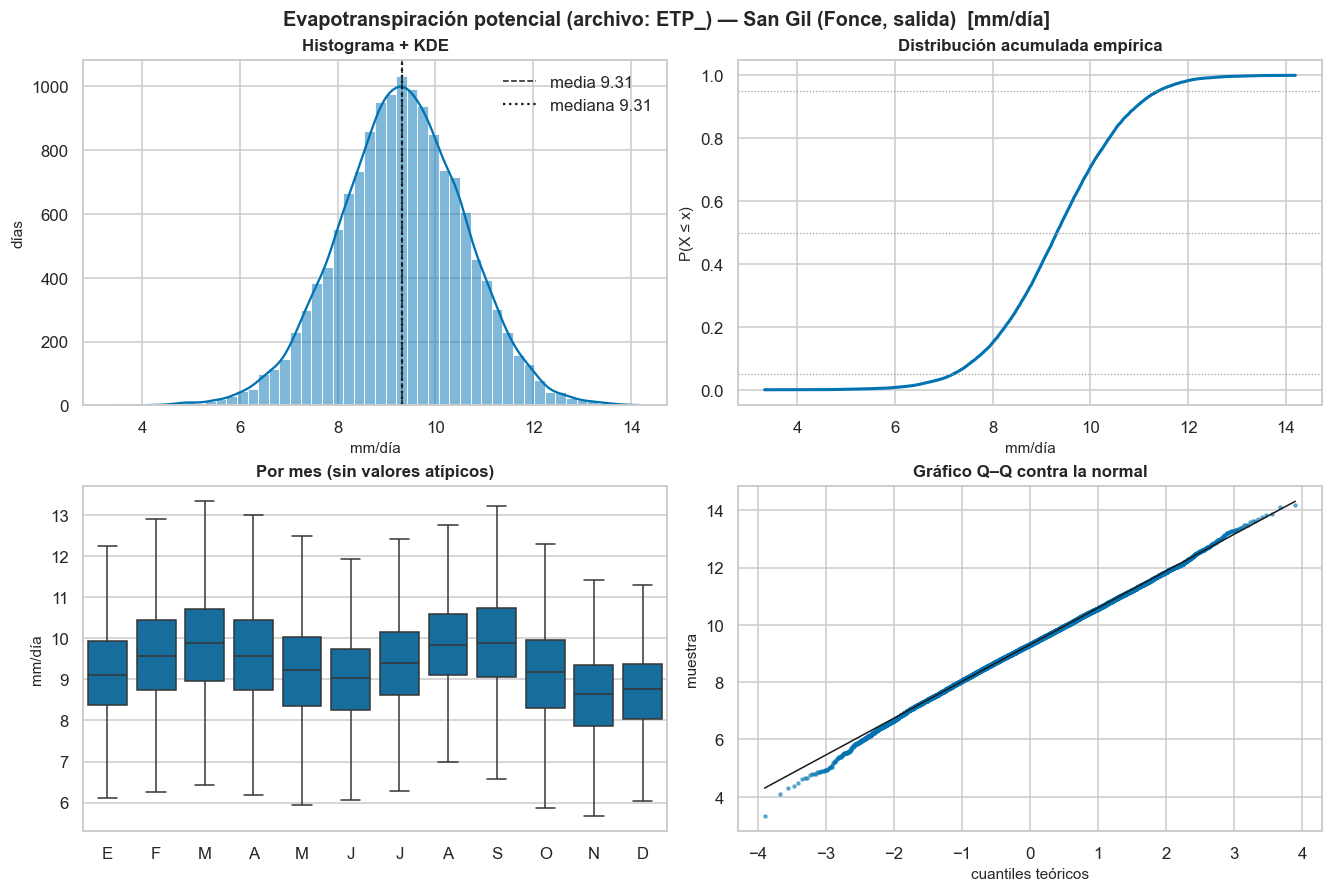

n                 14410.00
media                 9.31
desv. estándar        1.28
asimetría            -0.08
mínimo                3.34
p5                    7.20
mediana               9.31
p95                  11.39
máximo               14.19
Name: Evapotranspiración potencial (archivo: ETP_) — San Gil (Fonce, salida), dtype: float64

In [4]:
v = VARIABLES["etp"]
panel_distribucion(datos[ID_ESTACION][v["col"]], f'{v["etiqueta"]} — {ESTACIONES[ID_ESTACION]}', v["unidad"], log=v["log"])

**Observaciones (San Gil).** La distribución es casi simétrica (asimetría ≈ −0.08) alrededor de una media de 9.3 mm/día, con poca
estacionalidad: las medias mensuales solo van de unos 8.6 mm/día (noviembre) a 9.9 (septiembre). Es lo esperable de una ETP
calculada con temperatura a 6.5° N, donde la temperatura casi no cambia a lo largo del año. La prueba de Shapiro rechaza la
normalidad (n es enorme), pero el gráfico Q–Q solo muestra desviaciones leves en las colas.

El problema es el **nivel**: 9.3 mm/día son unos 3 400 mm/año de evaporación potencial para una cuenca cuya elevación media es
2 264 m. Ver la sección 4.3.

### 4.2 Todas las estaciones

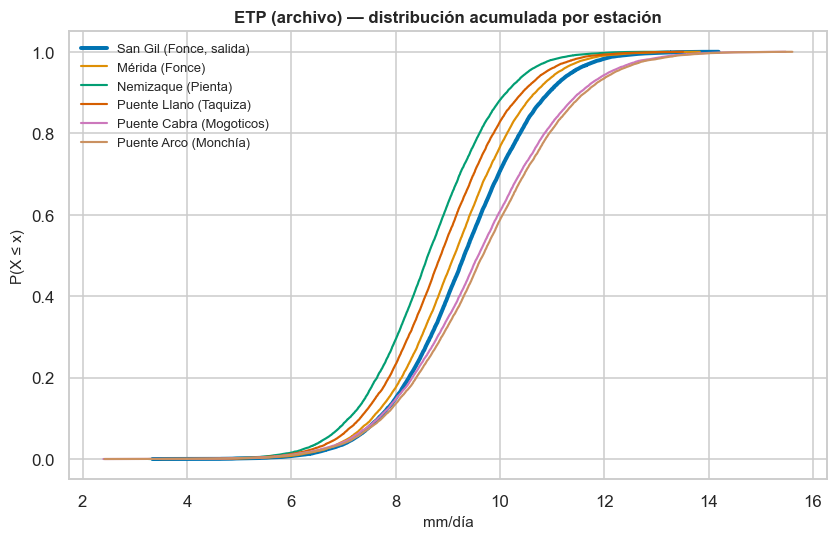

In [5]:
comparar_fda('etp', 'mm/día', 'ETP (archivo) — distribución acumulada por estación')

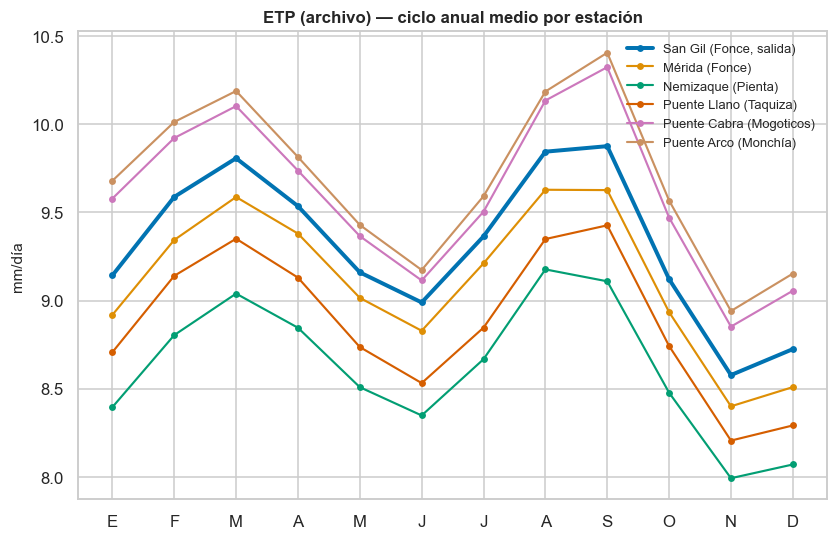

In [6]:
comparar_ciclo_mensual('etp', 'mm/día', 'ETP (archivo) — ciclo anual medio por estación')

La ETP sigue casi perfectamente a la elevación en las seis cuencas (correlación −0.97 con la elevación media de la cuenca): Monchía
(1 952 m) y Mogoticos (1 860 m) tienen los valores más altos, de 9.6–9.7 mm/día, y Pienta (2 693 m) el más bajo, 8.6. Es el comportamiento
esperado de una ETP basada en temperatura. Todas las estaciones comparten la misma forma anual.

### 4.3 ¿Es razonable esta ETP?

Recalcular Hargreaves con las mismas t_min y t_max y la latitud de la estación da un valor mucho menor. Si los valores del archivo fueran
un cálculo correcto de Hargreaves, el cociente *archivo / recalculada* estaría cerca de 1.

In [7]:
filas = []
for id_est, nombre in ESTACIONES.items():
    d = datos[id_est][["etp", "etp_hg", "precip", "caudal_mm"]].dropna(subset=["etp", "etp_hg"])
    p_anual = d.precip.mean() * 365.25
    filas.append({
        "estación": nombre,
        "ETP archivo (mm/año)": d.etp.mean() * 365.25,
        "ETP Hargreaves (mm/año)": d.etp_hg.mean() * 365.25,
        "cociente archivo / Hargreaves (mediana)": (d.etp / d.etp_hg).median(),
        "P CHIRPS (mm/año)": p_anual,
        "aridez en CAMELS-COL (ETP/P)": MAESTRA.loc[id_est, "aridity"],
        "aridez con Hargreaves (ETP/P)": d.etp_hg.mean() * 365.25 / p_anual,
    })
pd.DataFrame(filas).set_index("estación").round(2)

,ETP archivo (mm/año),ETP Hargreaves (mm/año),cociente archivo / Hargreaves (mediana),P CHIRPS (mm/año),aridez en CAMELS-COL (ETP/P),aridez con Hargreaves (ETP/P)
estación,,,,,,
"San Gil (Fonce, salida)",3400.38,1231.62,2.76,2208.51,1.54,0.56
Mérida (Fonce),3329.34,1197.99,2.77,2153.45,1.55,0.56
Nemizaque (Pienta),3147.47,1121.47,2.80,2041.30,1.54,0.55
Puente Llano (Taquiza),3238.66,1163.99,2.78,2106.11,1.54,0.55
Puente Cabra (Mogoticos),3504.38,1278.71,2.73,2223.43,1.58,0.58
Puente Arco (Monchía),3535.18,1290.82,2.73,2404.26,1.47,0.54


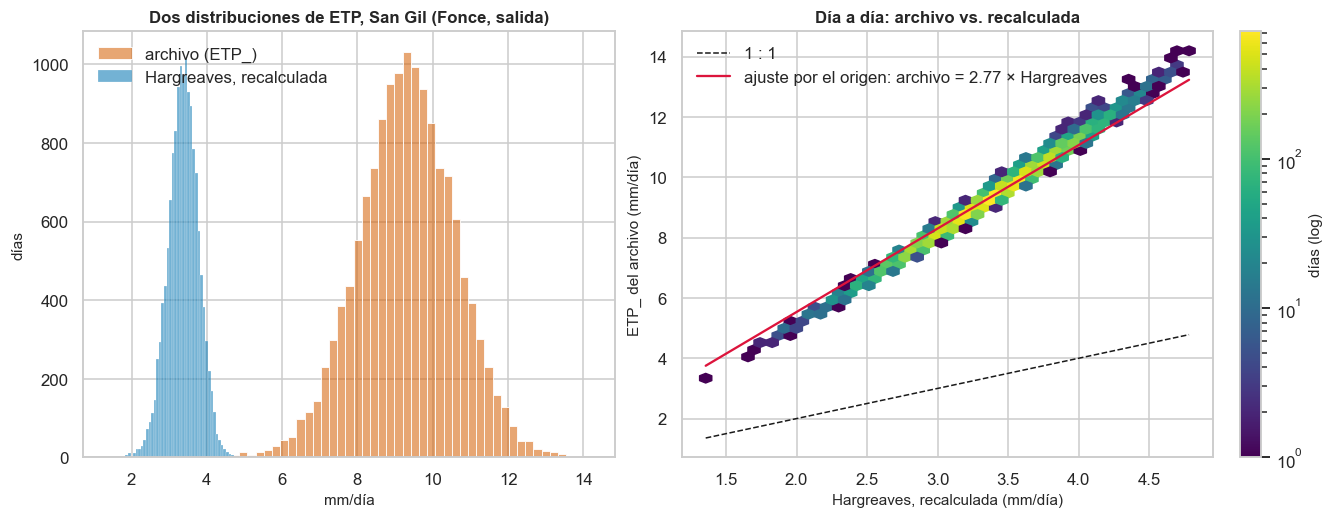

archivo / recalculada: mediana 2.76, rango 5–95 % 2.65–2.86


In [8]:
d = datos[ID_ESTACION][["etp", "etp_hg"]].dropna()
pendiente = (d.etp * d.etp_hg).sum() / (d.etp_hg ** 2).sum()          # pendiente de mínimos cuadrados por el origen
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)

sns.histplot(d.etp, bins=50, color=PAL[3], alpha=0.55, label="archivo (ETP_)", ax=ax[0])
sns.histplot(d.etp_hg, bins=50, color=PAL[0], alpha=0.55, label="Hargreaves, recalculada", ax=ax[0])
ax[0].set(title=f"Dos distribuciones de ETP, {ESTACIONES[ID_ESTACION]}", xlabel="mm/día", ylabel="días"); ax[0].legend(frameon=False)

hb = ax[1].hexbin(d.etp_hg, d.etp, gridsize=40, cmap="viridis", mincnt=1, bins="log")
xx = np.array([d.etp_hg.min(), d.etp_hg.max()])
ax[1].plot(xx, xx, "k--", lw=1, label="1 : 1")
ax[1].plot(xx, pendiente * xx, color="crimson", lw=1.5, label=f"ajuste por el origen: archivo = {pendiente:.2f} × Hargreaves")
ax[1].set(title="Día a día: archivo vs. recalculada", xlabel="Hargreaves, recalculada (mm/día)", ylabel="ETP_ del archivo (mm/día)"); ax[1].legend(frameon=False, loc="upper left")
fig.colorbar(hb, ax=ax[1], label="días (log)")
plt.show()

cociente = d.etp / d.etp_hg
print(f"archivo / recalculada: mediana {cociente.median():.2f}, rango 5–95 % {cociente.quantile(.05):.2f}–{cociente.quantile(.95):.2f}")

**Qué muestra esto (San Gil).** La ETP del archivo es en promedio unas **2.75 veces** el valor recalculado (≈ 3 400 frente a ≈ 1 230 mm/año) y el
cociente es casi constante de un día a otro (aprox. 2.65–2.86): las dos series son casi proporcionales, así que el archivo parece una versión
*escalada* de un cálculo de Hargreaves, no un método distinto. (No es perfectamente proporcional: el hexbin se curva un poco, así que una recta por
el origen se pasa en los valores bajos y se queda corta en los altos.)

- Una causa probable es que la radiación Ra se haya usado en **MJ m⁻² día⁻¹ en lugar de mm día⁻¹** (un factor de 1/0.408 = 2.45). Eso explica
  la mayor parte de la diferencia pero no toda (queda cerca de un 12 %), así que es una hipótesis, no un diagnóstico.
- El valor que sale de la fórmula correcta (≈ 1 230 mm/año) coincide con la ETP regional que el propio artículo de CAMELS-COL mapea a partir del IDEAM
  (1 200–1 400 mm/año); los 3 400 mm/año del archivo no.
- Cambia cómo se ve la cuenca: el índice de aridez que el archivo reporta para el Fonce (≈ 1.5, «subhúmedo») pasa a ≈ 0.6 (húmedo) con la ETP
  recalculada (tabla de arriba).

El cociente es 2.6–2.8 en todas las estaciones de la tabla, y también encontré 2.6–2.7 en dos cuencas sin relación (Timba y Atrato). Sin comprobar:
si se cumple en las 346 cuencas.
**Para balances hídricos o modelación hidrológica no uses `ETP_` tal cual**; usa `etp_hg` o, mejor, la ETP de ERA5.

## 5. Caudal

### 5.1 Una estación — San Gil

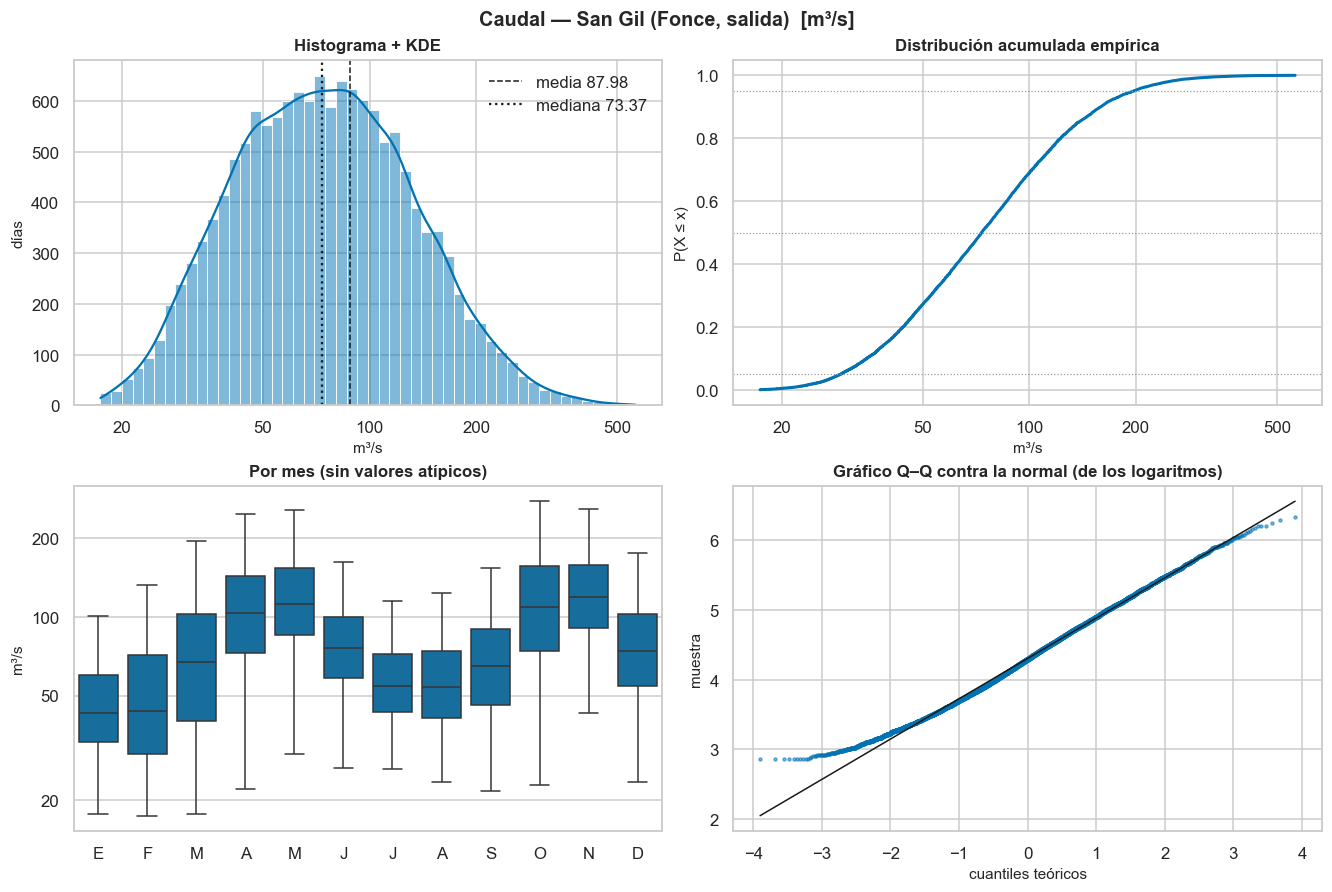

n                    14410.00
media                   87.98
desv. estándar          56.14
asimetría                1.92
mínimo                  17.40
p5                      29.50
mediana                 73.37
p95                    196.90
máximo                 562.00
asimetría del log        0.15
Name: Caudal — San Gil (Fonce, salida), dtype: float64

In [9]:
v = VARIABLES["caudal"]
panel_distribucion(datos[ID_ESTACION][v["col"]], f'{v["etiqueta"]} — {ESTACIONES[ID_ESTACION]}', v["unidad"], log=v["log"])

**Observaciones (San Gil).** El caudal tiene una fuerte asimetría positiva (asimetría ≈ +1.9; media 88 m³/s frente a mediana 73). Su **logaritmo es casi
simétrico** (asimetría ≈ 0.15), así que el caudal diario es cercano a lognormal: el gráfico Q–Q en escala log es recto en el centro, se aplana en el
extremo bajo (el caudal casi nunca baja de unos 17 m³/s) y se curva ligeramente por debajo de la recta en las crecientes más grandes. Los diagramas de caja
mensuales muestran las **dos temporadas de lluvias**: el caudal tiene picos en abril–mayo y octubre–noviembre, y los meses más secos son enero–febrero y julio–agosto.

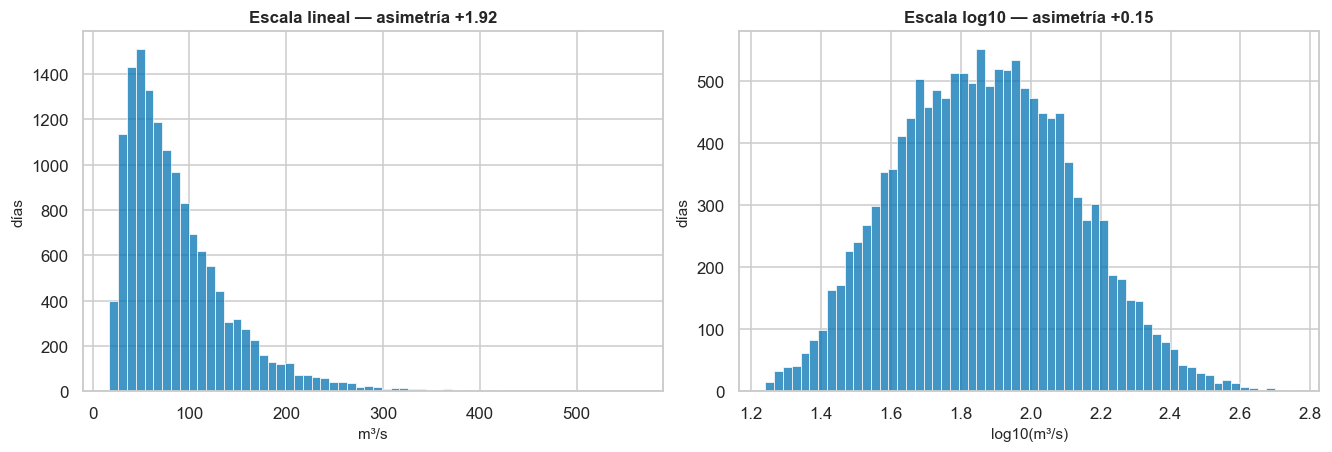

In [10]:
q = datos[ID_ESTACION].caudal.dropna()
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
sns.histplot(q, bins=60, color=PAL[0], ax=ax[0]); ax[0].set(title=f"Escala lineal — asimetría {stats.skew(q):+.2f}", xlabel="m³/s", ylabel="días")
sns.histplot(np.log10(q), bins=60, color=PAL[0], ax=ax[1]); ax[1].set(title=f"Escala log10 — asimetría {stats.skew(np.log10(q)):+.2f}", xlabel="log10(m³/s)", ylabel="días")
plt.show()

### 5.2 Comparación entre estaciones — caudal específico (mm/día)

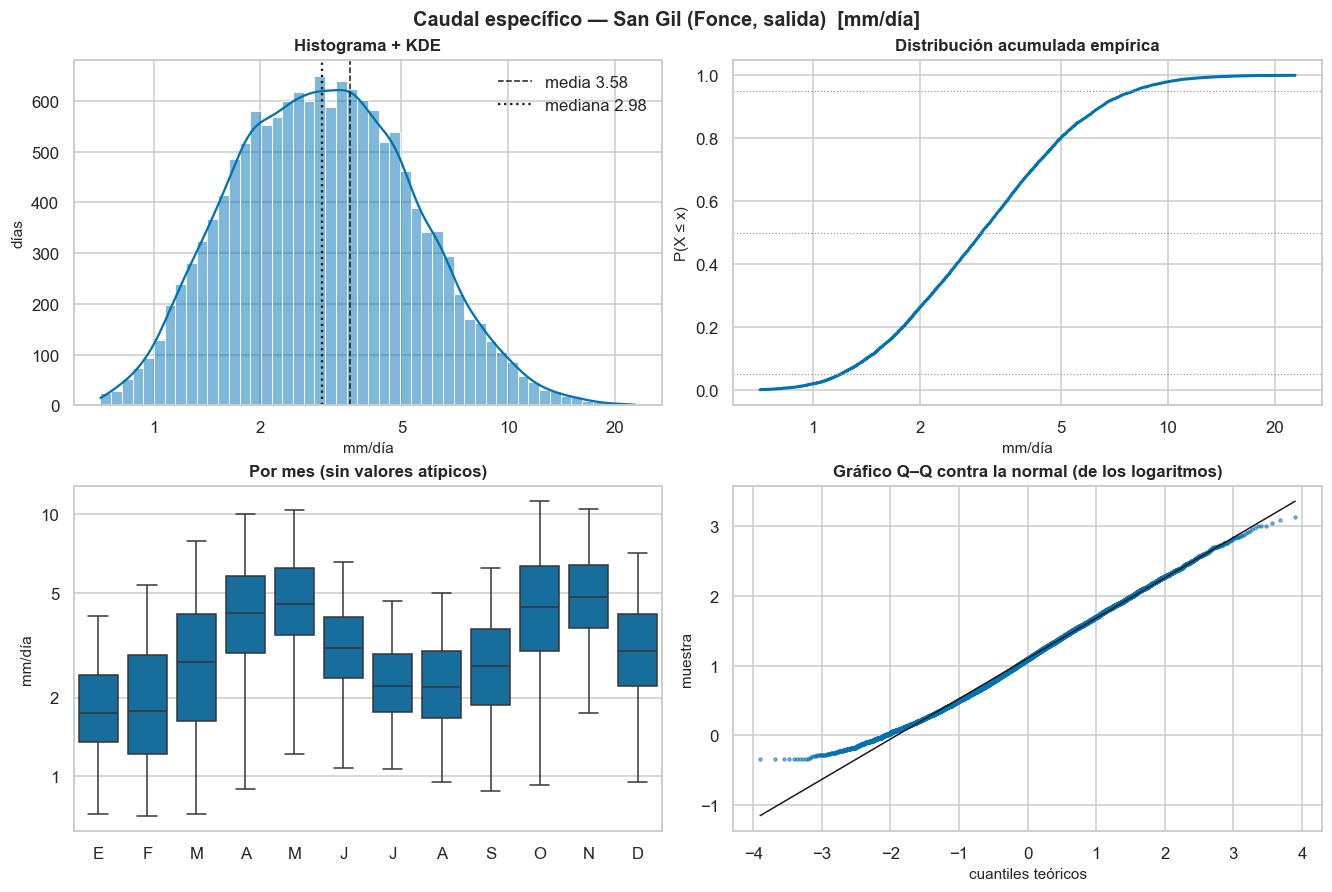

n                    14410.00
media                    3.58
desv. estándar           2.28
asimetría                1.92
mínimo                   0.71
p5                       1.20
mediana                  2.98
p95                      8.01
máximo                  22.86
asimetría del log        0.15
Name: Caudal específico — San Gil (Fonce, salida), dtype: float64

In [11]:
panel_distribucion(datos[ID_ESTACION].caudal_mm, f'Caudal específico — {ESTACIONES[ID_ESTACION]}', 'mm/día', log=True)

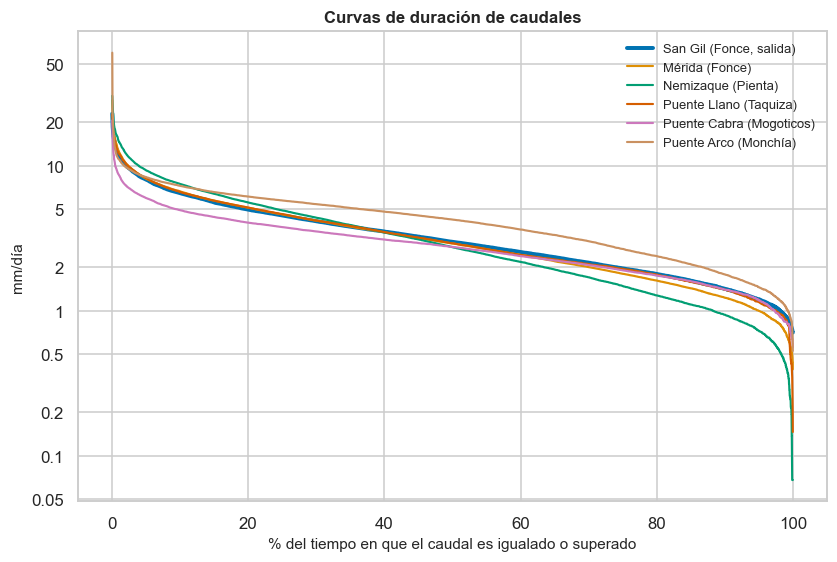

In [12]:
curva_duracion()

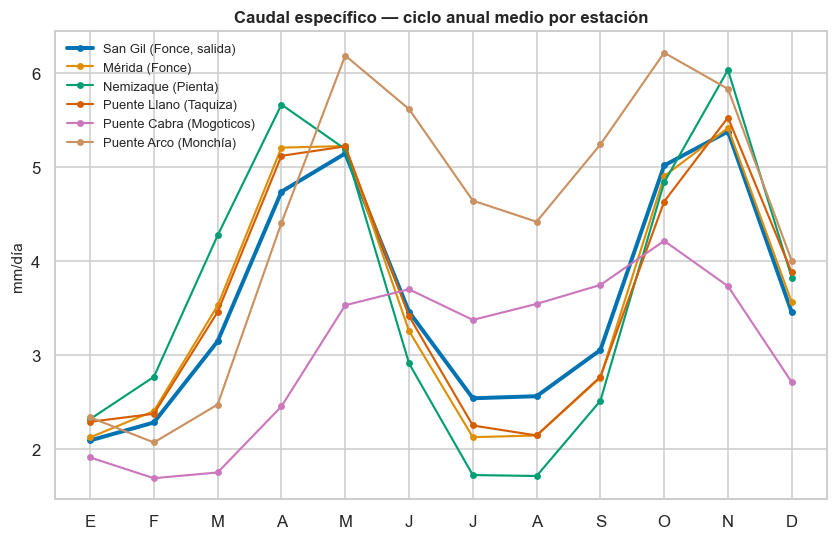

In [13]:
comparar_ciclo_mensual('caudal_mm', 'mm/día', 'Caudal específico — ciclo anual medio por estación')

Una vez que el caudal se divide por el área, la salida (San Gil) y sus tres subcuencas grandes (Mérida, Pienta, Taquiza) tienen casi la misma
media (3.55–3.64 mm/día), lo que sugiere que las curvas de calibración son coherentes entre ellas. **Monchía** rinde más (≈ 4.5 mm/día)
y **Mogoticos** menos (≈ 3.0); Mogoticos además tiene el mayor índice de flujo base (0.80), lo que se ve como una curva de duración más plana. Nemizaque
(Pienta) tiene los caudales bajos más bajos y cae hasta cerca de 0.07 mm/día en el extremo derecho de la curva: es su único día con caudal cero.

### 5.3 ¿Coinciden los cuantiles de caudal con los atributos de CAMELS-COL?

CAMELS-COL publica `Q5` y `Q95` (los cuantiles del 5 % y del 95 % del caudal diario, en mm/día). Si los calculamos con la serie diaria deberían coincidir.

In [14]:
filas = []
for id_est, nombre in ESTACIONES.items():
    s = datos[id_est].caudal_mm.dropna()
    filas.append({"estación": nombre,
                  "Q5 calculado": s.quantile(.05), "Q5 CAMELS-COL": MAESTRA.loc[id_est, "Q5"],
                  "mediana calculada": s.median(),
                  "Q95 calculado": s.quantile(.95), "Q95 CAMELS-COL": MAESTRA.loc[id_est, "Q95"]})
t = pd.DataFrame(filas).set_index("estación").round(2)
t["coinciden"] = (np.isclose(t["Q5 calculado"], t["Q5 CAMELS-COL"], atol=0.02) & np.isclose(t["Q95 calculado"], t["Q95 CAMELS-COL"], atol=0.02))
t

,Q5 calculado,Q5 CAMELS-COL,mediana calculada,Q95 calculado,Q95 CAMELS-COL,coinciden
estación,,,,,,
"San Gil (Fonce, salida)",1.20,1.20,2.98,8.01,8.01,True
Mérida (Fonce),1.00,1.00,2.91,8.11,8.11,True
Nemizaque (Pienta),0.73,0.73,2.74,9.28,9.28,True
Puente Llano (Taquiza),1.15,1.15,2.92,8.20,8.20,True
Puente Cabra (Mogoticos),1.18,1.18,2.75,5.98,5.98,True
Puente Arco (Monchía),1.46,1.46,4.25,8.34,8.34,True


## 6. Explora cualquier otra variable

`explorar(variable, id_estacion)` dibuja las cuatro vistas para cualquier entrada de `VARIABLES`. Agrega más ampliando el diccionario, por ejemplo:

```python
VARIABLES["t_max"]  = dict(col="t_max",  etiqueta="Temperatura máxima (MSWX)", unidad="°C",     log=False)
VARIABLES["precip"] = dict(col="precip", etiqueta="Precipitación (CHIRPS)",     unidad="mm/día", log=False)   # muchos días en cero
```

In [15]:
def explorar(variable="etp", id_estacion=ID_ESTACION):
    v = VARIABLES[variable]
    return panel_distribucion(datos[id_estacion][v["col"]], f'{v["etiqueta"]} — {ESTACIONES[id_estacion]}', v["unidad"], log=v["log"])

# ejemplo: explorar("caudal_mm", 24027040)

In [16]:
# Menús desplegables opcionales (requieren `pip install ipywidgets`; todavía no está instalado en este entorno)
try:
    import ipywidgets as w
    w.interact(explorar, variable=list(VARIABLES), id_estacion=[(n, i) for i, n in ESTACIONES.items()])
except ImportError:
    print("ipywidgets no está instalado: llama a explorar('caudal_mm', 24027040), o instala ipywidgets con `pip install ipywidgets` para tener menús.")

ipywidgets no está instalado: llama a explorar('caudal_mm', 24027040), o instala ipywidgets con `pip install ipywidgets` para tener menús.
